<a href="https://colab.research.google.com/github/profession-ai-data-engineering-master/programmazione-con-python-progetto2/blob/main/profession_ai_data_engineering_progetto2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisi dell'Andamento degli Indici Azionari S&P 500 ed EURO STOXX 50
## Descrizione del progetto

L'azienda Global Investment Insights è una società di consulenza finanziaria che si occupa di fornire analisi dettagliate sull'andamento dei mercati azionari. Il progetto si concentra su due indici fondamentali: - S&P 500: che rappresenta il mercato azionario statunitense. - EURO STOXX 50: che descrive l'andamento del mercato azionario europeo.

L'obiettivo è studiare l'andamento degli ultimi 10 anni di questi indici e trarne insights preziosi che possano aiutare gli investitori a prendere decisioni strategiche.

L'analisi fornita da Global Investment Insights offrirà agli investitori una panoramica chiara e dettagliata sui trend storici di due dei principali indici azionari globali. Grazie all'approfondimento sui rendimenti giornalieri e mensili, nonché all'identificazione dei giorni di maggiore volatilità, gli investitori potranno pianificare strategie di investimento più informate e ridurre il rischio associato ai loro portafogli. Il calcolo del volume medio giornaliero, inoltre, fornirà indicazioni utili sull’interesse degli investitori e sui periodi di maggiore attività di mercato, consentendo decisioni più oculate e mirate.

## Obiettivi del progetto
L'analisi prevede i seguenti step: - Calcolo del rendimento percentuale mensile e annuale. - Calcolo del rendimento medio giornaliero per ciascun indice e per ciascun giorno della settimana. - Individuazione dei giorni con il rendimento giornaliero più alto e più basso per entrambi gli indici. - Calcolo del volume medio giornaliero di scambi per ciascun indice.

## Dataset
Puoi scaricare i dataset da qui: https://drive.google.com/drive/folders/1j9tlNmoUyqlOQd8HInHoa950Gccji4mb?usp=sharing

I dataset forniti, sp500.csv per l'indice S&P 500 e euro50.csv per l'indice EURO STOXX 50, contengono le seguenti colonne:

- Date: la data della rilevazione.
- Open: il prezzo di apertura di quel giorno.
- High: il prezzo massimo raggiunto durante il giorno.
- Low: il prezzo minimo raggiunto durante il giorno.
- Close: il prezzo di chiusura del giorno.
- Volume: il numero di scambi avvenuti durante quel giorno.

## Steps del progetto
### 1. Calcolo del rendimento percentuale
Per ciascun indice, sarà calcolato il rendimento percentuale utilizzando la formula della variazione percentuale tra i prezzi di chiusura di un periodo rispetto al periodo precedente: - Rendimento mensile - Rendimento annuale

### 2. Rendimento medio giornaliero per giorno della settimana
Calcolare il rendimento medio giornaliero di ciascun indice per ogni giorno della settimana. Questa analisi permetterà di identificare eventuali trend particolari legati a giorni specifici (ad esempio, l'andamento delle borse il lunedì rispetto agli altri giorni della settimana).

### 3. Giorni con rendimento massimo e minimo
Individuare, per ciascun indice, i giorni con il rendimento giornaliero più alto e quelli con il rendimento giornaliero più basso. Questa informazione è utile per analizzare le giornate di estrema volatilità sui mercati e comprenderne le cause.

### 4. Calcolo del volume medio giornaliero
Analizzare il volume medio giornaliero di scambi per ciascun indice. Questo dato rappresenta il livello di attività di mercato e può aiutare a capire l'interesse degli investitori nei due indici.

## Metodologia
- I rendimenti percentuali verranno calcolati come variazione percentuale del prezzo di chiusura rispetto al periodo precedente (giornaliero, mensile o annuale).
- Per il rendimento medio giornaliero, i dati verranno aggregati in base al giorno della settimana per ciascun indice.
- Per i giorni con rendimento massimo e minimo, verranno individuati i valori estremi del rendimento giornaliero nei due dataset.

---

# Pianificazione e Scelte Progettuali
Per questo progetto ho cercato, come fatto nel precedente, di non inventare la
ruota da 0. La mia ricerca si è concentrata nel trovare una metodologia o un framework standard per svolgere il compito nella maniera più standardizzata e
professionale possibile.

Inizialmente ho trovato come standard il framework **CRISP - DM**, ma ho deciso di non adottarlo in quanto avrei dovuto piegarlo troppo alle esigenze tutto sommato "semplici" di questo progetto (Lo tengo comunque in considerazione per futuri progetti inerenti al data mining e all'uso di AI).

Successivamente mi sono inbattuto in **[OSEMN (awesomw)](https://www.datascience-pm.com/osemn/)** ed in esso ho trovato un buon compromesso in termini di qualità del flusso di lavoro e possibilità di
reinterpretralo e adattarlo alle necessità specifiche del progetto.

OSEMEN mette a disposizione 5 fasi, da intendersi iterative e non lineari, per
partire dal dato ed estrapolare a fine processo le dovute conclusioni/informazioni avendo la garanzia di essersi appoggiati ad una metodologia matura e testata in ambienti enterprise (since 2010).

Di seguito un tabella riepilogativa delle 5 fasi che compongono il processo:


|Lettera|Fase|Scopo sintetico|
|---|---|---|
|**O**|**Obtain** – Ottenere i dati|Raccogliere i dati necessari da fonti interne o esterne, in modo legale ed etico.|
|**S**|**Scrub** – Pulire i dati|Rimuovere errori, duplicati e valori mancanti; trasformare i dati in un formato utilizzabile.|
|**E**|**Explore** – Esplorare i dati|Comprendere struttura, pattern e relazioni tramite statistiche descrittive e visualizzazioni.|
|**M**|**Model** – Modellare|Costruire modelli predittivi o descrittivi per rispondere alla domanda di business.|
|**N**|**iNterpret** – Interpretare|Tradurre i risultati in azioni/decisioni, comunicarli agli stakeholder e monitorarne l’impatto.|



In [ ]:
# @title Imports
import pandas as pd
import os
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
from datetime import datetime,date

In [ ]:
# @title Settaggi
plt.style.use('dark_background')

## 1. Obtain (ottenere il dato)

Per questa prima fase ho estrapolato il link di download diretto di entrambi i file ed ho recuperato il dataset tramite pandas (Sospettavo dall'esempio visto a lezione che con un link di download diretto avrebbe fatto il suo mestiere).

### 1.1 Caricamento dei Dati di EURO STOXX 50

In [ ]:
euro_50_df_raw = pd.read_csv("https://drive.google.com/uc?id=1BwYroL994llOrEu5_XmuGmLsQw_41AUO")
display(euro_50_df_raw.head().style.set_caption("EURO STOXX 50"))
display(euro_50_df_raw.describe(include='all'))

,Date,Open,High,Low,Close,Volume
0,2014-04-15 00:00:00+02:00,3130.149902,3139.659912,3091.189941,3091.520020,59163400
1,2014-04-16 00:00:00+02:00,3116.459961,3139.260010,3113.469971,3139.260010,63114700
2,2014-04-17 00:00:00+02:00,3140.120117,3156.639893,3121.820068,3155.810059,66521300
3,2014-04-22 00:00:00+02:00,3161.689941,3201.250000,3157.399902,3199.689941,49270000
4,2014-04-23 00:00:00+02:00,3197.389893,3198.600098,3175.219971,3175.969971,48916800


,Date,Open,High,Low,Close,Volume
count,2512,2512.000000,2512.000000,2512.000000,2512.000000,2.512000e+03
unique,2512,NaN,NaN,NaN,NaN,NaN
top,2024-03-20 00:00:00+01:00,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,3571.883194,3595.150499,3547.638109,3572.171145,4.193444e+07
std,NaN,459.604033,458.528795,461.980153,460.763910,1.907896e+07
min,NaN,2388.939941,2461.570068,2302.840088,2385.820068,0.000000e+00
25%,NaN,3244.664978,3269.692505,3226.249939,3246.219971,2.967560e+07
50%,NaN,3486.239990,3506.835083,3465.694946,3488.714966,3.749665e+07
75%,NaN,3827.487488,3848.577515,3799.049988,3828.907532,4.997290e+07


### 1.2 Caricamento dei Dati di S&P 500

In [ ]:
sp_500_df_raw = pd.read_csv("https://drive.google.com/uc?id=1L16kcdAQ33NJZPGvkyN6ly_PFO6eFOBD")
display(sp_500_df_raw.head().style.set_caption("S&P 500"))
display(sp_500_df_raw.describe(include='all'))

,Date,Open,High,Low,Close,Volume
0,2014-04-15 00:00:00-04:00,153.202298,154.046360,151.689653,153.937714,157093000
1,2014-04-16 00:00:00-04:00,154.999072,155.558996,154.313784,155.550644,105197000
2,2014-04-17 00:00:00-04:00,155.341722,156.202502,155.074289,155.767929,105255000
3,2014-04-21 00:00:00-04:00,155.809663,156.361234,155.617453,156.311081,68329000
4,2014-04-22 00:00:00-04:00,156.469867,157.447646,156.386304,157.021439,85790000


,Date,Open,High,Low,Close,Volume
count,2517,2517.000000,2517.000000,2517.000000,2517.000000,2.517000e+03
unique,2517,NaN,NaN,NaN,NaN,NaN
top,2024-04-15 00:00:00-04:00,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,288.681508,290.271015,286.973003,288.740224,9.128904e+07
std,NaN,101.167582,101.786490,100.516270,101.200970,4.570609e+07
min,NaN,153.202298,154.046360,151.689653,153.937714,8.372180e+06
25%,NaN,190.363430,190.905818,189.663299,190.428207,6.235830e+07
50%,NaN,262.118824,263.595099,260.394405,262.737061,7.929390e+07
75%,NaN,388.344756,391.171649,384.777956,388.540436,1.054429e+08


### 1.3 Conclusioni

Dando un primo sguardo ai dataset grezzi noto che:
1. È necessario uniformare il fusorario per le date.
2. Nel dataset di EURO STOXX 50 ho degli outlier sulla feature "Volume" (Non ritengo valido il valore 0 sul minimo della feature).
3. È necessario escludere dall'analisi i giorni in cui uno dei due fondi non è
   presente(2517 vs 2512). Ritengo corretto effettuare l'analisi a parità di giornate considerando lo stesso contesto di mercato e condizione geopolitica
   (magari un giorno uno dei 2 underperforma per una ragione valida e per l'altro manca il dato ma possibilmente nel mondo reale ha anch'esso underperformato).

## 2. Scrub (Pulire il dato)

### 2.1 Copio i dati prima dello SCRUB

In [ ]:
euro_50_df = euro_50_df_raw.copy()
sp_500_df = sp_500_df_raw.copy()

### 2.2 Verifico la presenza di valori nulli o duplicati

In [ ]:
display(Markdown("### Verifica valori nulli o duplicati - EURO STOXX 50"))
display(euro_50_df.isnull().sum())
display(euro_50_df.duplicated().sum())
display(Markdown("### Verifica valori nulli o duplicati - S&P 500"))
display(sp_500_df.isnull().sum())
display(sp_500_df.duplicated().sum())


### Verifica valori nulli o duplicati - EURO STOXX 50

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


np.int64(0)

### Verifica valori nulli o duplicati - S&P 500

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


np.int64(0)

Non riscontro valori nulli o duplicati nei dataset di partenza.

### 2.3 Uniformo le date di entrambi i datasets a utc

In [ ]:
euro_50_df["Date"] = pd.to_datetime(euro_50_df["Date"],utc=True,format='%Y-%m-%d %H:%M:%S%z')
sp_500_df["Date"] = pd.to_datetime(sp_500_df["Date"],utc=True, format='%Y-%m-%d %H:%M:%S%z')


### 2.4 Eliminazione tuple con Volume a 0 da dataset EURO STOXX 50

In [ ]:
euro_50_df = euro_50_df[euro_50_df["Volume"] != 0]

### 2.4 Normalizzo le date alla mezzanotte di ogni giorno

In [ ]:
# normalizzo le date alla mezzanotte di ogni giorno, essendo l'orario
# trascurabile in quanto per ogni dataset abbiamo una misurazione giornaliera ma
# con orari differenti in utc (per fusorario).

euro_50_df = euro_50_df.assign(
    date_only = euro_50_df["Date"].dt.normalize()
)

sp_500_df = sp_500_df.assign(
    date_only = sp_500_df["Date"].dt.normalize()
)



### 2.5 Normalizzo le date alla mezzanotte di ogni giorno

In [ ]:
# Elimino i giorni dove manca uno dei due indici
date_comuni = set(euro_50_df["date_only"]).intersection(set(sp_500_df["date_only"]))
euro_50_df = euro_50_df[euro_50_df["date_only"].isin(date_comuni)].loc[:, euro_50_df.columns != 'date_only'].copy()
sp_500_df = sp_500_df[sp_500_df["date_only"].isin(date_comuni)].loc[:, sp_500_df.columns != 'date_only'].copy()

## 3. Explore (Esplorare il dato)

### 3.1 Data Dictionary






In virtù dell'esperienza maturata nella mia professione ritengo come punto fondamentale la definizione del "Data Dictionary" che descriva in modo formale
le feature dei dataset. Ritengo che comprende a fondo le business rules dietro
le feature consente di analizzare e manipolare i dati con consapevolezza e di ridurre gli errori concettuali.

di seguito data dictionary:

(per generarlo mi sono aiutato con [link](https://www.tablesgenerator.com/markdown_tables))


#### 3.1.1 Data Dictionary - EURO STOXX 50

In [ ]:
display(euro_50_df.dtypes)
display(euro_50_df.head(3))

,0
Date,"datetime64[ns, UTC]"
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


,Date,Open,High,Low,Close,Volume
1,2014-04-15 22:00:00+00:00,3116.459961,3139.260010,3113.469971,3139.260010,63114700
2,2014-04-16 22:00:00+00:00,3140.120117,3156.639893,3121.820068,3155.810059,66521300
3,2014-04-21 22:00:00+00:00,3161.689941,3201.250000,3157.399902,3199.689941,49270000


Lo **EURO STOXX 50** è un indice azionario paneuropeo che rappresenta le 50 principali società europee per capitalizzazione di mercato e liquidità. È stato creato nel 1998 da **STOXX Limited**, una joint venture fondata da **Deutsche Börse AG**, **Dow Jones & Company** e **SWX Group**.

L'indice include società provenienti da **17 paesi europei**, tra cui: Austria, Belgio, Danimarca, Finlandia, Francia, Germania, Irlanda, Italia, Lussemburgo, Paesi Bassi, Norvegia, Portogallo, Spagna, Svezia, Svizzera e Regno Unito. Le aziende selezionate appartengono a diversi settori, rendendo l’indice rappresentativo delle principali economie del continente europeo.

Lo EURO STOXX 50 è disponibile in più valute (**EUR, USD, CAD, GBP, JPY**) e in varie versioni (Price, Net Return, Gross Return), ed è ampiamente utilizzato come benchmark per prodotti finanziari come ETF, derivati e strumenti strutturati.

📚 **Fonte:** [Wikipedia - EURO STOXX 50](https://it.wikipedia.org/wiki/STOXX_Europe_50)

| Nome Variabile | Tipo Dato | Descrizione                                                                        | Esempio                   | Note di Business o Regole                                                                                                                              |
| -------------- | --------- | ---------------------------------------------------------------------------------- | ------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Date           | datetime64[ns, UTC]      | Data di riferimento dell’osservazione dell’indice.                                 | 2014-04-14 22:00:00+00:00 | Utilizzare formato ISO 8601. Ogni riga rappresenta un giorno di contrattazione (trading day). |
| Open           | float64     | Valore di apertura dell’indice EURO STOXX 50 alla prima transazione della giornata.      | 3130.149902               | Deve essere minore o uguale a `High` e maggiore o uguale a `Low`.                                                                                      |
| High           | float64     | Valore massimo raggiunto dall’indice nella giornata di contrattazione.             | 3139.659912               | Deve essere maggiore o uguale a `Open`, `Close` e `Low`.                                                                                               |
| Low            | float64     | Valore minimo raggiunto dall’indice nella giornata di contrattazione.              | 3091.189941               | Deve essere minore o uguale a `Open`, `Close` e `High`.                                                                                                |
| Close          | float64     | Valore finale dell’indice al termine della giornata di contrattazione.             | 3091.520020               | Rilevante per analisi storiche, calcolo delle performance e degli indicatori tecnici.                                                                  |
| Volume         | int64   | Numero totale di transazioni o contratti negoziati sull’indice in quella giornata. | 59163400                  | Nota importante: un indice, come lo EURO STOXX 50, non è un titolo che si compra o si vende direttamente,<br> ma rappresenta un insieme di aziende. Quindi, il campo Volume non indica gli scambi sull’indice stesso,<br> ma una stima della somma degli scambi avvenuti su tutte le azioni delle aziende che compongono l’indice.<br> Serve per avere un’idea di quanta attività di mercato c'è stata complessivamente quel giorno. |

#### 3.1.2 Data Dictionary - S\&P 500

In [ ]:
display(sp_500_df.dtypes)
display(sp_500_df.head(3))

,0
Date,"datetime64[ns, UTC]"
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


,Date,Open,High,Low,Close,Volume
0,2014-04-15 04:00:00+00:00,153.202298,154.046360,151.689653,153.937714,157093000
1,2014-04-16 04:00:00+00:00,154.999072,155.558996,154.313784,155.550644,105197000
3,2014-04-21 04:00:00+00:00,155.809663,156.361234,155.617453,156.311081,68329000


Lo **S\&P 500** (Standard & Poor's 500) è uno degli indici azionari più importanti al mondo, rappresentando le **500 maggiori società statunitensi** per capitalizzazione di mercato. È stato introdotto nel **1957** da **Standard & Poor’s**, oggi parte di **S\&P Global**.

L’indice copre circa l’**80% della capitalizzazione totale del mercato azionario statunitense**, rendendolo un benchmark chiave per misurare le performance del mercato azionario USA nel suo complesso. Le società che lo compongono operano in **11 settori** economici secondo la classificazione GICS (Global Industry Classification Standard), tra cui tecnologia, sanità, finanza, energia e beni di consumo.

Lo S\&P 500 è disponibile in diverse versioni: **Price Index**, **Total Return Index** e **Net Total Return Index**, e viene frequentemente utilizzato come benchmark per ETF, fondi comuni e strumenti derivati. La valuta di riferimento è il **dollaro statunitense (USD)**.

📚 **Fonte:** [Wikipedia - S\&P 500](https://it.wikipedia.org/wiki/S%26P_500)

| Nome Variabile | Tipo Dato | Descrizione                                                                         | Esempio                   | Note di Business o Regole                                                                                                                                               |
| -------------- | --------- | ----------------------------------------------------------------------------------- | ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Date           | datetime64[ns, UTC]      | Data di riferimento dell’osservazione dell’indice.                                  | 2014-04-15 00:00:00-04:00 | Formato ISO 8601. Ogni riga rappresenta un giorno di contrattazione (trading day).                           |
| Open           | float64     | Valore di apertura dell’indice S\&P 500 alla prima transazione della giornata.      | 153.202298               | Deve essere minore o uguale a `High` e maggiore o uguale a `Low`.                                                                                                       |
| High           | float64     | Valore massimo raggiunto dall’indice nella giornata di contrattazione.              | 154.046360               | Deve essere maggiore o uguale a `Open`, `Close` e `Low`.                                                                                                                |
| Low            | float64     | Valore minimo raggiunto dall’indice nella giornata di contrattazione.               | 151.689653               | Deve essere minore o uguale a `Open`, `Close` e `High`.                                                                                                                 |
| Close          | float64     | Valore finale dell’indice al termine della giornata di contrattazione.              | 153.937714               | Usato per analisi storiche, calcolo delle performance, indicatori tecnici e valutazioni di fine giornata.                                                               |
| Volume         | int64   | Volume aggregato delle transazioni sulle azioni delle società comprese nell’indice. | 157093000                | Come per altri indici, il volume rappresenta la somma degli scambi sui titoli che compongono l’indice, <br>non sull’indice stesso, che non è acquistabile direttamente. |

### 3.2 Analisi Preliminare

#### Analisi Preliminare Utilities

In [ ]:
def analisi_preliminare(df: pd.core.frame.DataFrame) -> None:
    """
    Esegue un'analisi esplorativa preliminare su un DataFrame,
    mostrando dimensioni, tipi di dati, presenza di valori nulli
    e statistiche descrittive.

    :param pd.DataFrame df: Il DataFrame su cui eseguire l'analisi preliminare.
    :return: Nessun valore restituito. La funzione produce output visivo.
    :rtype: None
    """
    display(Markdown("### Dimensioni del dataset"))
    display(df.shape)

    display(Markdown("### Tipi di dati e presenza di valori nulli"))
    df.info()

    display(Markdown("### Statistiche descrittive"))
    display(df.describe(include='all'))

#### 3.2.1 Analisi Preliminare - EURO STOXX 50

In [ ]:
analisi_preliminare(euro_50_df)

### Dimensioni del dataset

(1950, 6)

### Tipi di dati e presenza di valori nulli

<class 'pandas.core.frame.DataFrame'>
Index: 1950 entries, 1 to 2510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    1950 non-null   datetime64[ns, UTC]
 1   Open    1950 non-null   float64            
 2   High    1950 non-null   float64            
 3   Low     1950 non-null   float64            
 4   Close   1950 non-null   float64            
 5   Volume  1950 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(4), int64(1)
memory usage: 106.6 KB


### Statistiche descrittive

,Date,Open,High,Low,Close,Volume
count,1950,1950.000000,1950.000000,1950.000000,1950.000000,1.950000e+03
mean,2019-04-19 00:28:29.538461440+00:00,3572.607431,3596.525955,3548.677343,3573.700554,4.349127e+07
min,2014-04-15 22:00:00+00:00,2388.939941,2461.570068,2345.300049,2385.820068,3.360000e+05
25%,2016-10-12 04:00:00+00:00,3244.259949,3269.920105,3226.074951,3247.375000,3.080135e+07
50%,2019-04-24 10:00:00+00:00,3486.704956,3507.155029,3466.209961,3490.709961,3.873050e+07
75%,2021-10-21 16:00:00+00:00,3827.522522,3848.982544,3793.414978,3827.724976,5.200800e+07
max,2024-04-11 22:00:00+00:00,5096.859863,5121.709961,5081.779785,5083.419922,2.358453e+08
std,NaN,460.861098,459.998262,463.126022,462.076179,1.896964e+07


#### 3.2.2 Analisi Preliminare - S&P 500

In [ ]:
analisi_preliminare(sp_500_df)

### Dimensioni del dataset

(1950, 6)

### Tipi di dati e presenza di valori nulli

<class 'pandas.core.frame.DataFrame'>
Index: 1950 entries, 0 to 2514
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   Date    1950 non-null   datetime64[ns, UTC]
 1   Open    1950 non-null   float64            
 2   High    1950 non-null   float64            
 3   Low     1950 non-null   float64            
 4   Close   1950 non-null   float64            
 5   Volume  1950 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(4), int64(1)
memory usage: 106.6 KB


### Statistiche descrittive

,Date,Open,High,Low,Close,Volume
count,1950,1950.000000,1950.000000,1950.000000,1950.000000,1.950000e+03
mean,2019-04-18 06:24:22.153846272+00:00,289.083613,290.689347,287.380886,289.150508,8.885962e+07
min,2014-04-15 04:00:00+00:00,153.202298,154.046360,151.689653,153.937714,3.091120e+07
25%,2016-10-11 10:00:00+00:00,190.286750,190.913964,189.709302,190.431709,6.136938e+07
50%,2019-04-23 16:00:00+00:00,262.686166,263.874487,260.756628,262.813202,7.725340e+07
75%,2021-10-20 22:00:00+00:00,389.503416,392.170872,385.914974,389.085335,1.015582e+08
max,2024-04-11 04:00:00+00:00,523.830017,524.380005,521.909973,523.169983,5.072443e+08
std,NaN,101.422355,102.020750,100.758199,101.429520,4.463549e+07


### 3.3 Feature Engineering

#### Feature Engineering Utilities

In [ ]:

def aggiungi_prc_rendimento_per_periodo(df: pd.DataFrame, colonne_raggruppamento: list[str]) -> pd.DataFrame:
    """
    Aggiunge al DataFrame una colonna che rappresenta
    la variazione percentuale del valore 'Close' rispetto al mese precedente,
    calcolata per ciascun gruppo specificato.

    :param pd.DataFrame df: Il DataFrame di partenza.
    :param list[str] colonne_raggruppamento: Lista di colonne su cui effettuare il raggruppamento per il calcolo del rendimento.
    :return: Il DataFrame originale con la nuova colonna.
    :rtype: pd.DataFrame
    :raises ValueError: se il DataFrame è vuoto, mancano colonne richieste o se i parametri sono malformati.
    """
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Il parametro 'df' deve essere un pandas DataFrame.")
    if not isinstance(colonne_raggruppamento, list) or not all(isinstance(col, str) for col in colonne_raggruppamento):
        raise TypeError("Il parametro 'colonne_raggruppamento' deve essere una lista di stringhe.")
    if df.empty:
        raise ValueError("Il DataFrame fornito è vuoto.")
    colonne_necessarie = set(colonne_raggruppamento + ['Close'])
    colonne_mancanti = colonne_necessarie - set(df.columns)
    if colonne_mancanti:
        raise ValueError(f"Colonne mancanti nel DataFrame: {colonne_mancanti}")
    try:
        nome_nuova_colonna=f"prc_rendimento_{'_'.join(colonne_raggruppamento)}"
        raggruppato_df = df.groupby(colonne_raggruppamento).tail(1)[list(set(colonne_raggruppamento + ['Close']))]
        raggruppato_df = raggruppato_df.sort_values(colonne_raggruppamento).copy()
        raggruppato_df[nome_nuova_colonna] = (
            (raggruppato_df["Close"] - raggruppato_df["Close"].shift(1)) / raggruppato_df["Close"].shift(1)
        ) * 100
        df = df.copy()
        df[nome_nuova_colonna] = pd.NA
        df.loc[raggruppato_df.index, nome_nuova_colonna] = raggruppato_df[nome_nuova_colonna]
        return df
    except Exception as e:
        raise RuntimeError(f"Errore durante il calcolo del rendimento mensile: {e}")


#### 3.3.1 Aggiunta Features

In [ ]:
euro_50_df_featured = euro_50_df.copy()
sp_500_df_featured = sp_500_df.copy()

euro_50_df_featured = euro_50_df_featured.reset_index()
sp_500_df_featured = sp_500_df_featured.reset_index()

euro_50_df_featured.set_index("Date", inplace=True)
sp_500_df_featured.set_index("Date", inplace=True)

euro_50_df_featured.sort_index(inplace=True)
sp_500_df_featured.sort_index(inplace=True)

euro_50_df_featured["giorno_della_settimana"] = euro_50_df_featured.index.day_of_week
sp_500_df_featured["giorno_della_settimana"] = sp_500_df_featured.index.day_of_week

euro_50_df_featured["nome_giorno_della_settimana"] = euro_50_df_featured.index.day_name()
sp_500_df_featured["nome_giorno_della_settimana"] = sp_500_df_featured.index.day_name()

euro_50_df_featured["periodo_giornaliero"] = euro_50_df_featured.index.date
sp_500_df_featured["periodo_giornaliero"] = sp_500_df_featured.index.date

euro_50_df_featured["prc_rendimento_giornaliero"] = ((euro_50_df_featured["Close"] - euro_50_df_featured["Close"].shift(1))/euro_50_df_featured["Close"].shift(1))*100
sp_500_df_featured["prc_rendimento_giornaliero"] = ((sp_500_df_featured["Close"] - sp_500_df_featured["Close"].shift(1))/sp_500_df_featured["Close"].shift(1))*100

euro_50_df_featured["periodo_mensile"] = (euro_50_df_featured.index + pd.offsets.MonthEnd(0)).date
sp_500_df_featured["periodo_mensile"] = (euro_50_df_featured.index + pd.offsets.MonthEnd(0)).date

euro_50_df_featured = aggiungi_prc_rendimento_per_periodo(euro_50_df_featured,["periodo_mensile"])
sp_500_df_featured = aggiungi_prc_rendimento_per_periodo(sp_500_df_featured,["periodo_mensile"])

euro_50_df_featured["periodo_annuale"] = (euro_50_df_featured.index + pd.offsets.YearEnd(0)).date
sp_500_df_featured["periodo_annuale"] = (euro_50_df_featured.index + pd.offsets.YearEnd(0)).date

euro_50_df_featured = aggiungi_prc_rendimento_per_periodo(euro_50_df_featured,["periodo_annuale"])
sp_500_df_featured = aggiungi_prc_rendimento_per_periodo(sp_500_df_featured,["periodo_annuale"])

#### 3.3.2 Vusualizzazione Datasets Featured

In [ ]:
display(Markdown("### Dataset featured - EURO 50"))
display(euro_50_df_featured.head())
display(euro_50_df_featured.tail())
display(Markdown("### Dataset featured - SP 500"))
display(sp_500_df_featured.head())
display(sp_500_df_featured.tail())

### Dataset featured - EURO 50

,index,Open,High,Low,Close,Volume,giorno_della_settimana,nome_giorno_della_settimana,periodo_giornaliero,prc_rendimento_giornaliero,periodo_mensile,prc_rendimento_periodo_mensile,periodo_annuale,prc_rendimento_periodo_annuale
Date,,,,,,,,,,,,,,
2014-04-15 22:00:00+00:00,1,3116.459961,3139.260010,3113.469971,3139.260010,63114700,1,Tuesday,2014-04-15,NaN,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-16 22:00:00+00:00,2,3140.120117,3156.639893,3121.820068,3155.810059,66521300,2,Wednesday,2014-04-16,0.527196,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-21 22:00:00+00:00,3,3161.689941,3201.250000,3157.399902,3199.689941,49270000,0,Monday,2014-04-21,1.390448,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-22 22:00:00+00:00,4,3197.389893,3198.600098,3175.219971,3175.969971,48916800,1,Tuesday,2014-04-22,-0.741321,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-23 22:00:00+00:00,5,3188.379883,3206.800049,3150.790039,3189.810059,47602100,2,Wednesday,2014-04-23,0.435775,2014-04-30,<NA>,2014-12-31,<NA>


,index,Open,High,Low,Close,Volume,giorno_della_settimana,nome_giorno_della_settimana,periodo_giornaliero,prc_rendimento_giornaliero,periodo_mensile,prc_rendimento_periodo_mensile,periodo_annuale,prc_rendimento_periodo_annuale
Date,,,,,,,,,,,,,,
2024-04-04 22:00:00+00:00,2505,5043.609863,5043.609863,4985.669922,5014.750000,36778900,3,Thursday,2024-04-04,-1.104564,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-08 22:00:00+00:00,2507,5038.729980,5038.729980,4981.229980,4990.899902,24097700,0,Monday,2024-04-08,-0.475599,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-09 22:00:00+00:00,2508,5006.500000,5037.180176,4951.189941,5000.830078,28802000,1,Tuesday,2024-04-09,0.198966,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-10 22:00:00+00:00,2509,4994.149902,5010.089844,4934.399902,4966.680176,30613200,2,Wednesday,2024-04-10,-0.682885,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-11 22:00:00+00:00,2510,4986.029785,5023.899902,4935.029785,4955.009766,27782600,3,Thursday,2024-04-11,-0.234974,2024-04-30,-2.526058,2024-12-31,9.584109


### Dataset featured - SP 500

,index,Open,High,Low,Close,Volume,giorno_della_settimana,nome_giorno_della_settimana,periodo_giornaliero,prc_rendimento_giornaliero,periodo_mensile,prc_rendimento_periodo_mensile,periodo_annuale,prc_rendimento_periodo_annuale
Date,,,,,,,,,,,,,,
2014-04-15 04:00:00+00:00,0,153.202298,154.046360,151.689653,153.937714,157093000,1,Tuesday,2014-04-15,NaN,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-16 04:00:00+00:00,1,154.999072,155.558996,154.313784,155.550644,105197000,2,Wednesday,2014-04-16,1.047781,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-21 04:00:00+00:00,3,155.809663,156.361234,155.617453,156.311081,68329000,0,Monday,2014-04-21,0.488868,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-22 04:00:00+00:00,4,156.469867,157.447646,156.386304,157.021439,85790000,1,Tuesday,2014-04-22,0.454451,2014-04-30,<NA>,2014-12-31,<NA>
2014-04-23 04:00:00+00:00,5,156.962953,157.046517,156.528381,156.653732,73869000,2,Wednesday,2014-04-23,-0.234176,2014-04-30,<NA>,2014-12-31,<NA>


,index,Open,High,Low,Close,Volume,giorno_della_settimana,nome_giorno_della_settimana,periodo_giornaliero,prc_rendimento_giornaliero,periodo_mensile,prc_rendimento_periodo_mensile,periodo_annuale,prc_rendimento_periodo_annuale
Date,,,,,,,,,,,,,,
2024-04-04 04:00:00+00:00,2509,523.520020,523.869995,512.760010,513.070007,96858100,3,Thursday,2024-04-04,-1.220609,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-08 04:00:00+00:00,2511,519.150024,520.179993,517.890015,518.719971,48401800,0,Monday,2024-04-08,1.101207,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-09 04:00:00+00:00,2512,520.500000,520.750000,514.349976,519.320007,68124400,1,Tuesday,2024-04-09,0.115676,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-10 04:00:00+00:00,2513,513.479980,516.159973,512.090027,514.119995,82652800,2,Wednesday,2024-04-10,-1.001312,2024-04-30,<NA>,2024-12-31,<NA>
2024-04-11 04:00:00+00:00,2514,515.679993,519.479980,512.080017,518.000000,70099000,3,Thursday,2024-04-11,0.754689,2024-04-30,-0.988203,2024-12-31,9.003637


### 3.4 Analisi Quesiti

#### 3.4.1 Q1 - Calcolo del rendimento percentuale

In [ ]:
def q1_organizza_df(df,periodo,valore,nome_indice):
    """
    Organizza un DataFrame selezionando le colonne specificate,
    aggiungendo un campo di indice azionario e impostando un MultiIndex
    basato sul periodo e sul nome dell'indice.

    :param pd.DataFrame df: Il DataFrame di partenza contenente almeno le colonne `periodo` e `valore`.
    :param str periodo: Il nome della colonna da utilizzare come primo livello dell'indice.
    :param str valore: Il nome della colonna contenente i valori numerici da analizzare.
    :param str nome_indice: Il nome da assegnare alla colonna 'indice_azionario' per identificare il dataset.
    :return: Un DataFrame riorganizzato con MultiIndex (`periodo`, `indice_azionario`) e la colonna `valore`.
    :rtype: pd.DataFrame
    """
    df_response = df[[periodo,valore]]
    df_response = df_response.reset_index()
    df_response = df_response[[periodo,valore]]
    df_response = df_response.assign(indice_azionario = nome_indice)
    df_response = df_response.set_index([periodo,"indice_azionario"])
    return df_response

def q1_genera_df_completo(dfs,unstack,valore):
    """
    Combina una lista di DataFrame in un unico DataFrame,
    rimuove i valori mancanti, e ristruttura il DataFrame
    utilizzando `unstack` per creare una tabella pivot.

    :param list[pd.DataFrame] dfs: Lista di DataFrame da concatenare.
    :param str unstack: Nome del livello dell'indice da "unstackare" (es. 'indice_azionario').
    :param str valore: Il nome della colonna da utilizzare come valore nella tabella pivot.
    :return: Un DataFrame pivotato, ordinato e privo di valori NaN.
    :rtype: pd.DataFrame
    """
    df_response = pd.concat(dfs)

    df_response = df_response.sort_index()
    df_response = df_response.dropna()

    df_response = (
    df_response[valore]
    .unstack(unstack)
    .sort_index()
    )
    return df_response

def q1_line_chart(df, title, ylabel, xlabel, legend_title):
    """
    Crea e mostra un grafico a linee a partire da un DataFrame,
    configurando etichette, titolo e legenda.

    :param pd.DataFrame df: Il DataFrame i cui valori verranno tracciati.
    :param str title: Titolo del grafico.
    :param str ylabel: Etichetta dell'asse Y.
    :param str xlabel: Etichetta dell'asse X.
    :param str legend_title: Titolo della legenda per identificare le linee.
    :return: Nessun valore restituito. Il grafico viene mostrato a schermo.
    :rtype: None
    """
    fig, ax = plt.subplots(figsize=(12, 5))
    df.plot(ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.legend(title=legend_title)
    plt.tight_layout()
    plt.show()


##### 3.4.1.1 Analisi - Q1

**Q1 - Analisi Rendimenti Giornalieri**

In [ ]:
q1_df_euro_50_giornaliero = q1_organizza_df(
    euro_50_df_featured,
    "periodo_giornaliero",
    "prc_rendimento_giornaliero",
    "EURO STOXX 50"
    )
q1_df_sp_500_giornaliero = q1_organizza_df(
    sp_500_df_featured,
    "periodo_giornaliero",
    "prc_rendimento_giornaliero",
    "S&P 500"
    )
q1_df_giornaliero = q1_genera_df_completo(
    [q1_df_sp_500_giornaliero,q1_df_euro_50_giornaliero],
    "indice_azionario",
    "prc_rendimento_giornaliero"
    )


In [ ]:
display(q1_df_giornaliero)

indice_azionario,EURO STOXX 50,S&P 500
periodo_giornaliero,,
2014-04-16,0.527196,1.047781
2014-04-21,1.390448,0.488868
2014-04-22,-0.741321,0.454451
2014-04-23,0.435775,-0.234176
2014-04-24,-1.329551,0.202748
...,...,...
2024-04-04,-1.104564,-1.220609
2024-04-08,-0.475599,1.101207
2024-04-09,0.198966,0.115676


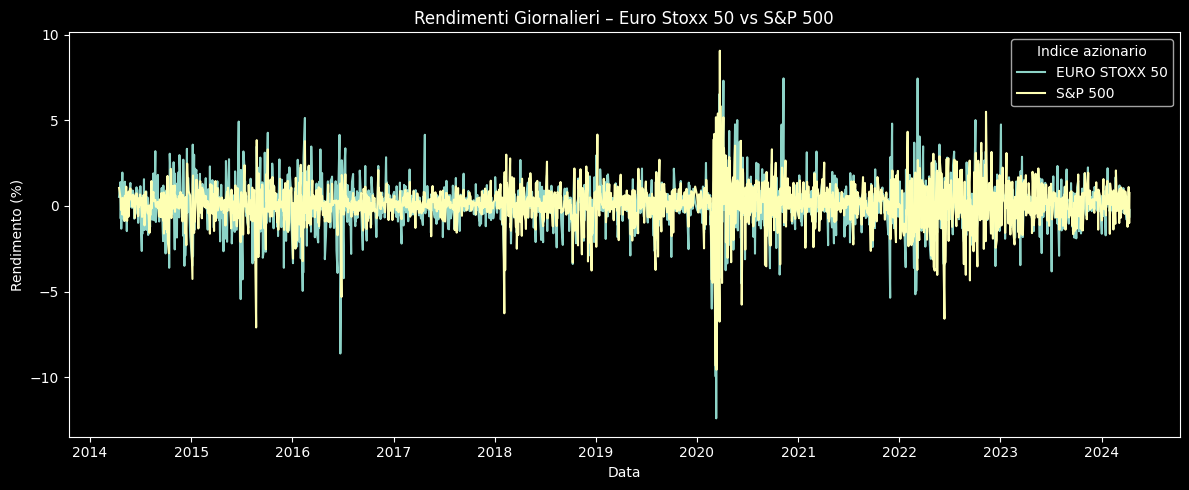

In [ ]:
q1_line_chart(
    df = q1_df_giornaliero,
    title = "Rendimenti Giornalieri – Euro Stoxx 50 vs S&P 500",
    ylabel = "Rendimento (%)",
    xlabel = "Data",
    legend_title = "Indice azionario"
    )

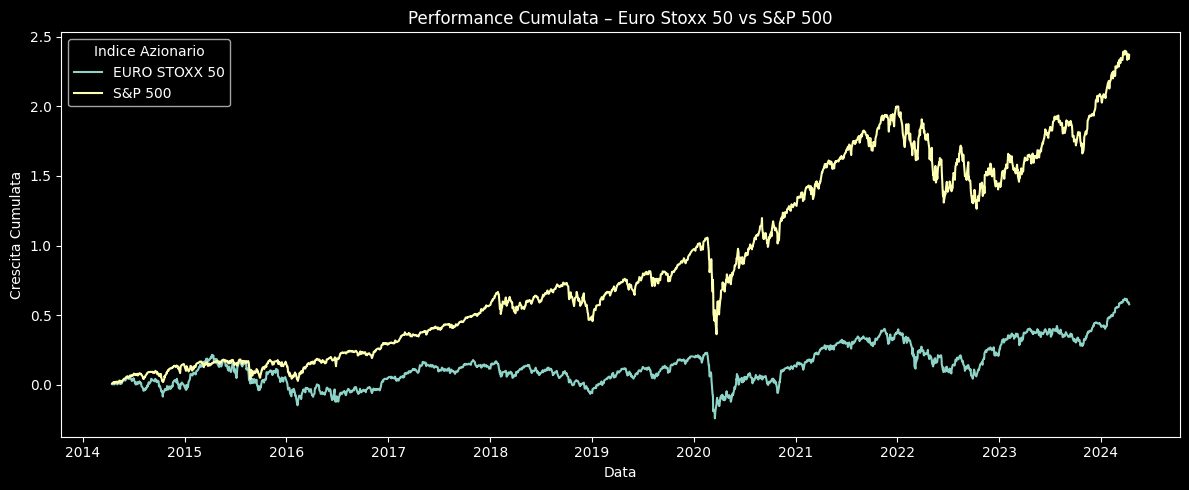

In [ ]:
q1_df_giornaliero_cumulative = (1 + q1_df_giornaliero/100).cumprod() - 1

q1_line_chart(
    df=q1_df_giornaliero_cumulative,
    title="Performance Cumulata – Euro Stoxx 50 vs S&P 500",
    ylabel="Crescita Cumulata",
    xlabel="Data",
    legend_title="Indice Azionario"
)

**Q1 - Analisi Rendimenti Mensili**

In [ ]:
q1_df_euro_50_mensile = q1_organizza_df(
    euro_50_df_featured,
    "periodo_mensile",
    "prc_rendimento_periodo_mensile",
    "EURO 500"
    )
q1_df_sp_500_mensile = q1_organizza_df(
    sp_500_df_featured,
    "periodo_mensile",
    "prc_rendimento_periodo_mensile",
    "SP 500"
    )
q1_df_mensile = q1_genera_df_completo(
    [q1_df_sp_500_mensile,q1_df_euro_50_mensile],
    "indice_azionario",
    "prc_rendimento_periodo_mensile"
    )


In [ ]:
display(q1_df_mensile)

indice_azionario,EURO 500,SP 500
periodo_mensile,,
2014-05-31,1.444796,2.460699
2014-06-30,0.434872,2.228984
2014-07-31,-4.394375,0.643743
2014-08-31,1.833404,1.604256
2014-09-30,0.707621,-1.098783
...,...,...
2023-12-31,2.334274,4.869131
2024-01-31,2.58645,1.29854
2024-02-29,5.524507,5.218682


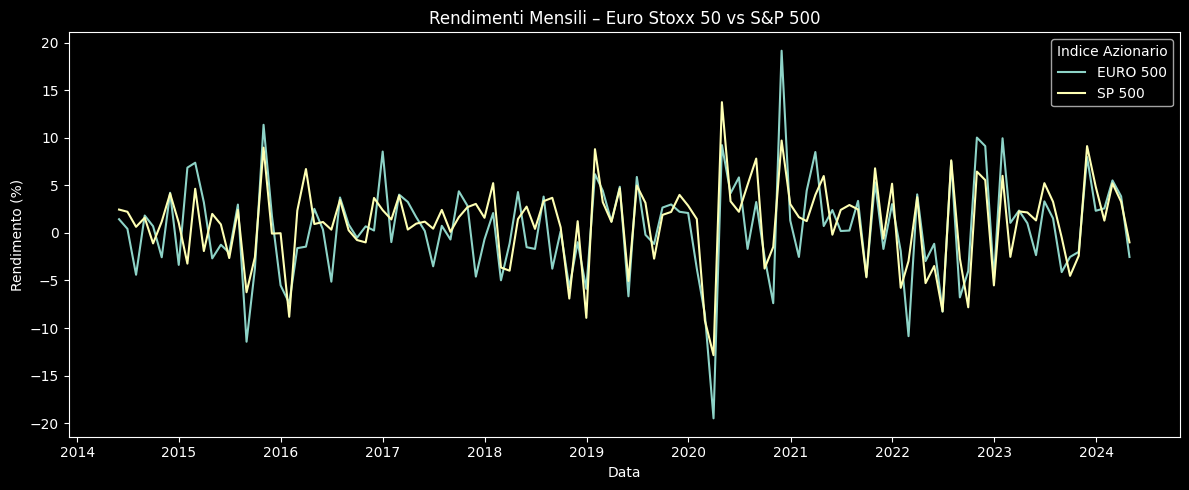

In [ ]:
q1_line_chart(
    df = q1_df_mensile,
    title = "Rendimenti Mensili – Euro Stoxx 50 vs S&P 500",
    ylabel = "Rendimento (%)",
    xlabel = "Data",
    legend_title = "Indice Azionario"
    )

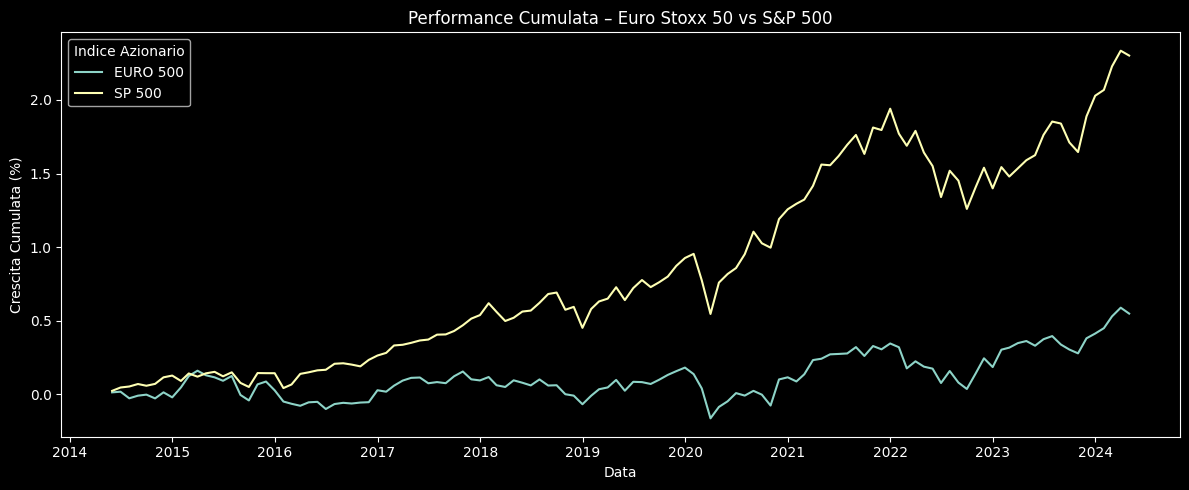

In [ ]:
q1_df_mensile_cumulative = (1 + q1_df_mensile/100).cumprod() - 1

q1_line_chart(
    df = q1_df_mensile_cumulative,
    title = "Performance Cumulata – Euro Stoxx 50 vs S&P 500",
    ylabel = "Crescita Cumulata (%)",
    xlabel = "Data",
    legend_title = "Indice Azionario"
    )

**Q1 - Analisi Rendimenti Annuali**

In [ ]:
q1_df_euro_50_annuale = q1_organizza_df(
    euro_50_df_featured,
    "periodo_annuale",
    "prc_rendimento_periodo_annuale",
    "EURO 500"
    )
q1_df_sp_500_annuale = q1_organizza_df(
    sp_500_df_featured,
    "periodo_annuale",
    "prc_rendimento_periodo_annuale",
    "SP 500"
    )
q1_df_annuale = q1_genera_df_completo(
    [q1_df_sp_500_annuale,q1_df_euro_50_annuale],
    "indice_azionario",
    "prc_rendimento_periodo_annuale"
    )

In [ ]:
display(q1_df_annuale)

indice_azionario,EURO 500,SP 500
periodo_annuale,,
2015-12-31,4.847974,1.418083
2016-12-31,0.077252,10.495532
2017-12-31,6.486511,21.719507
2018-12-31,-14.767005,-5.63257
2019-12-31,26.644299,32.646098
2020-12-31,-5.570198,17.172505
2021-12-31,20.564503,30.254872
2022-12-31,-11.900636,-18.392259
2023-12-31,19.190898,26.208813


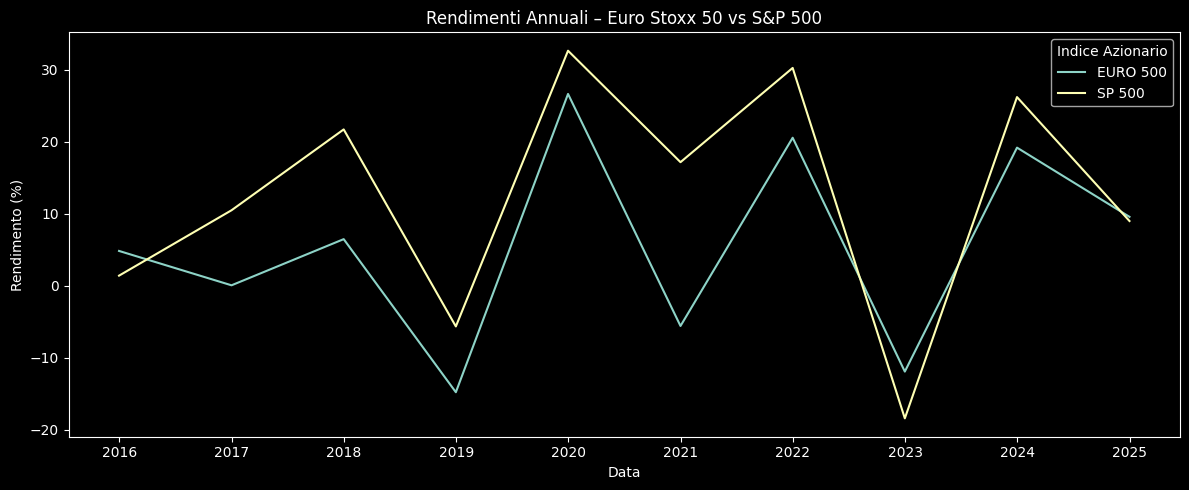

In [ ]:
q1_line_chart(
    df = q1_df_annuale,
    title = "Rendimenti Annuali – Euro Stoxx 50 vs S&P 500",
    ylabel = "Rendimento (%)",
    xlabel = "Data",
    legend_title = "Indice Azionario"
    )

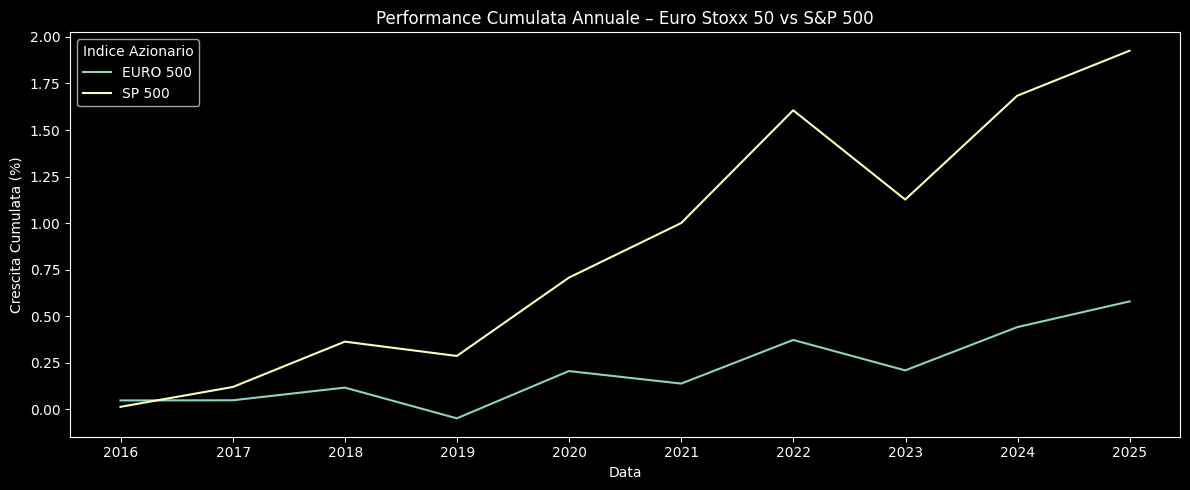

In [ ]:
q1_df_annuale_cumulative = (1 + q1_df_annuale/100).cumprod() - 1

q1_line_chart(
    df = q1_df_annuale_cumulative,
    title = "Performance Cumulata Annuale – Euro Stoxx 50 vs S&P 500",
    ylabel = "Crescita Cumulata (%)",
    xlabel = "Data",
    legend_title = "Indice Azionario"
    )

##### 3.4.1.2 Conclusioni - Q1


Per il quesito Q1 possiamo trarre le seguenti conclusioni:
- S&P 500 ha offerto un rendimento cumulativo su base decennale più stabile e performante rispetto EURO STOXX 50.
- S&P 500 ha mostrato maggiore capacità di recupero e resilienza in riferimento alla crisi del 2020 (covid 19) rispetto EURO STOXX 50 che ha faticato maggiormente nel recupero.
- Valutando densità e ampiezza delle linee in riferimento ai grafici dei rendimenti (soprattutto il giornaliero) si evince che EURO STOXX 50 è stato in media più volatile di S&P 500 in riferimento al periodo in questione.

**Nota**

Di seguito grafico che evidenzia l'andamento durare il periodo covid:

#### 3.4.2 Q2 - Rendimento medio giornaliero per giorno della settimana

In [ ]:
def q2_plot_barchart(df, xlabel: str, ylabel: str) -> None:
    """
    Genera, a partire da un DataFrame, un grafico a barre per ogni riga
    plottando con colori diversi le da confrontare.

    :param pandas.DataFrame df: il DataFrame da plottare.
    :param str xlabel: etichetta dell'asse X.
    :param str ylabel: etichetta dell'asse Y.
    :return: Nessun valore restituito; il grafico viene mostrato a schermo.
    :rtype: None
    """
    df.index.name = ''
    ax = df.plot.bar(
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0
    )
    plt.tight_layout()
    plt.show()




##### 3.4.2.1 Analisi - Q2

indice_azionario,EURO STOXX 50,S&P 500
nome_giorno_della_settimana,,
Monday,0.076387,0.103997
Tuesday,0.089346,0.064986
Wednesday,-0.050913,0.078655
Thursday,0.019421,0.033411


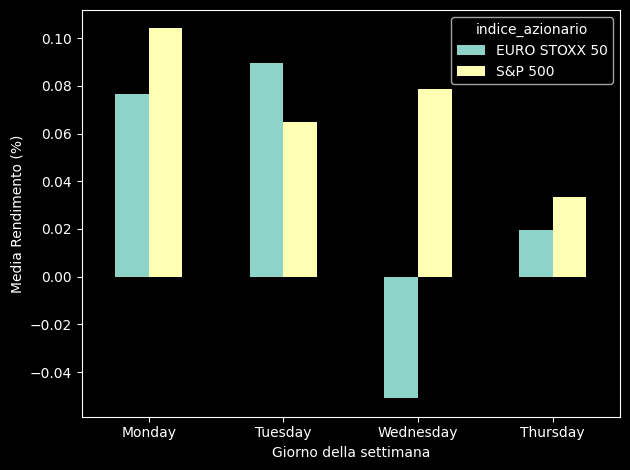

In [ ]:
q2_df_euro_50 = pd.DataFrame(euro_50_df_featured.groupby(["giorno_della_settimana","nome_giorno_della_settimana"])["prc_rendimento_giornaliero"].mean())
q2_df_euro_50 = q2_df_euro_50.assign(indice_azionario = "EURO STOXX 50")
q2_df_euro_50 = q2_df_euro_50.reset_index()
q2_df_euro_50 = q2_df_euro_50.set_index(["giorno_della_settimana","nome_giorno_della_settimana","indice_azionario"])
q2_df_sp_500 = pd.DataFrame(sp_500_df_featured.groupby(["giorno_della_settimana","nome_giorno_della_settimana"])["prc_rendimento_giornaliero"].mean())
q2_df_sp_500 = q2_df_sp_500.assign(indice_azionario = "S&P 500")
q2_df_sp_500 = q2_df_sp_500.reset_index()
q2_df_sp_500 = q2_df_sp_500.set_index(["giorno_della_settimana","nome_giorno_della_settimana","indice_azionario"])

q2_df = pd.concat([q2_df_euro_50,q2_df_sp_500])

q2_df = q2_df.sort_index()
q2_df = q2_df.dropna()

q2_df = (
    q2_df["prc_rendimento_giornaliero"]
    .unstack("indice_azionario")
    .sort_index()
)
q2_df = q2_df.reset_index()
q2_df = q2_df.drop(columns = "giorno_della_settimana")
q2_df = q2_df.set_index(["nome_giorno_della_settimana"])

display(q2_df)

q2_plot_barchart(q2_df, "Giorno della settimana", "Media Rendimento (%)")

##### 3.4.2.2 Conclusioni - Q2

Per il quesito Q2 possiamo giustificare i risultati sui valori medi settimanali con la presenza di fenomeni e meccanismi economici, quali:

- **Reverse Weekend Effect** (Lunedì): Il fenomeno del "reverse weekend effect", ovvero rendimenti mediamente positivi al lunedì sull’S\&P 500, è stato documentato in studi accademici. Ad esempio, una ricerca pubblicata su ScienceDirect evidenzia che questo effetto è una caratteristica unica del mercato statunitense. ([ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S1057521903000115))

- **Reazione ritardata dei listini dell’euro-area ai movimenti di Wall Street** (Martedì): Uno studio della Banca Centrale Europea (ECB) ha analizzato gli effetti delle politiche monetarie statunitensi sui mercati finanziari europei, evidenziando spillover significativi. Sebbene non si parli esplicitamente di un ritardo di un giorno, lo studio mostra come le decisioni della Federal Reserve influenzino i rendimenti obbligazionari e azionari delle banche europee. ([European Central Bank](https://www.ecb.europa.eu/pub/pdf/scpwps/ecb.wp2876~4bfa61fd60.en.pdf))

- **Composizione settoriale: S\&P 500 vs EURO STOXX 50** (EURO STOXX 50 calo il mercoledì (-0.050913)): La differente composizione settoriale tra l’S\&P 500 e l’EURO STOXX 50 incide sulle performance relative. Uno studio di Bitterroot Capital Advisors mostra che il settore tecnologico rappresenta il 23% dell’S\&P 500, ma solo il 6% dello Stoxx 600, mentre i settori finanziario ed energetico hanno un peso maggiore in Europa. ([aiolux.com](https://aiolux.com/contrasts/side-by-side?symbol_arr=FEZ%2CSPX), [bitterrootcapital.com](https://bitterrootcapital.com/wp-content/uploads/2022/06/WP-US-vs-Europe-Equities-Breaking-Down-the-Valuation-Difference.pdf))

- **Buy-back aziendali negli Stati Uniti** (S&P 500 massimo in Lunedì): Le aziende statunitensi spesso riaprono le finestre di buy-back il lunedì, immettendo liquidità nel mercato. Un articolo di AInvest riporta che circa il 40% delle aziende ha riaperto queste finestre, con un aumento previsto al 65% entro la fine della settimana. ([AInvest](https://www.ainvest.com/news/companies-rush-buyback-stocks-window-opens-2504/))

- **PMI europei pubblicati il mercoledì e impatto sull’EURO STOXX 50** (EURO STOXX 50 Mercoledì: −0.050913): I dati PMI europei, spesso pubblicati il mercoledì, possono influenzare l’andamento dell’EURO STOXX 50. Ad esempio, un articolo di Euronews riporta che un calo dell'attività del settore privato nell'eurozona ha avuto un impatto negativo sull'indice. ([euronews](https://www.euronews.com/business/2024/07/24/eurozone-private-sector-activity-falls-in-july-is-the-recovery-already-over))

#### 3.4.3 Q3 - Giorni con rendimento massimo e minimo

Per svolgere questo punto, invece di limitarmi semplicemente ai massimi e ai minimi, mi focalizzerò sul concetto di outliers. Per identificarli ho cercato online una metodologia standard e baserò la mia ricerca sul metodo [Metodo IQR](https://www.geeksforgeeks.org/handling-outliers-with-pandas/). Ho deciso di utilizzare IQR e non Z-score perchè documentandomi ho appreso che z-score richiede che i dati seguano una distrubuzione normale (Gaussiana) mentre IQR non fa assunzioni sulla distribuzione dei dati.

**Nota**

Ho utilizzato per entrambi un fattore di 5 (filtro più permissivo) per ridurre il numero di outliers.

In [ ]:
def trova_outlier_iqr(df, colonna, fattore=1.5):
    """
    Identifica gli outlier in una colonna numerica di un DataFrame utilizzando il metodo IQR.

    :param pandas.DataFrame df: il DataFrame su cui operare.
    :param str colonna: il nome della colonna da analizzare.
    :param float fattore: il moltiplicatore IQR (default: 1.5).
    :return: righe contenenti outlier nella colonna specificata.
    :rtype: pandas.DataFrame
    """
    Q1 = df[colonna].quantile(0.25)
    Q3 = df[colonna].quantile(0.75)
    IQR = Q3 - Q1

    soglia_bassa = Q1 - fattore * IQR
    soglia_alta = Q3 + fattore * IQR

    outliers = df[(df[colonna] < soglia_bassa) | (df[colonna] > soglia_alta)]

    return outliers


##### 3.4.3.1 Analisi - Q3

In [ ]:
q3_df_sp_500 = sp_500_df_featured[["periodo_giornaliero","prc_rendimento_giornaliero"]]
q3_df_sp_500 = q3_df_sp_500.reset_index()
q3_df_sp_500 = q3_df_sp_500.drop(columns="Date")
q3_df_sp_500 = q3_df_sp_500.set_index(["periodo_giornaliero"])
q3_df_sp_500 = q3_df_sp_500.dropna()
q3_df_sp_500 = trova_outlier_iqr(q3_df_sp_500,"prc_rendimento_giornaliero",5)

display(Markdown("### Outliers S&P 500"))
display(q3_df_sp_500)

### Outliers S&P 500

,prc_rendimento_giornaliero
periodo_giornaliero,
2015-08-24,-7.094181
2018-02-05,-6.268222
2020-03-09,-9.333420
2020-03-12,-9.567716
2020-03-23,-6.756063
2020-03-24,9.060337
2020-03-26,5.838982
2020-06-11,-5.764897
2022-06-13,-6.586292


| Data | Evento / Soprannome | Variazione S&P 500 | Cosa è successo | Fonti |
|------|--------------------|--------------------|-----------------|-------|
| 24 ago 2015 | «Black Monday» 2015 | **-7,09 %** | Paura di un brusco rallentamento dell’economia cinese dopo la svalutazione dello yuan e il crollo dell’indice di Shanghai (-8,5 %). Vendite in cascata: il Dow aprì -1 000 pt e chiuse -588 pt. | [The Guardian](https://www.theguardian.com/business/live/2015/aug/24/global-stocks-sell-off-deepens-as-panic-grips-markets-live), [CNN Money](https://money.cnn.com/2015/08/24/investing/stocks-markets-selloff-china-crash-dow/index.html) |
| 5 feb 2018 | “Volmageddon” | **-6,27 %** | Balzo del VIX (+116 %) che fece implodere gli ETN short-volatility (XIV & c.), innescando vendite forzate su futures e indici. Dow -1 175 pt (peggior calo in punti di sempre). | [NPR](https://www.npr.org/sections/thetwo-way/2018/02/05/583325123/stocks-extend-losses-with-dow-dropping-more-than-300-points-at-the-open), [Six Figure Investing](https://www.sixfigureinvesting.com/2019/02/what-caused-the-february-5th-2018-volatility-spike-xiv-termination/) |
| 9 mar 2020 | «Black Monday» 2020 | **-9,33 %** | Panico COVID-19 + guerra dei prezzi del petrolio (Arabia Saudita vs Russia, Brent -30 %). Scatta il primo *circuit breaker* dal 2013 dopo -7 % intraday. | [NPR](https://www.npr.org/2020/03/09/813619387/dow-dives-1-900-points-nyse-halts-trading-as-stock-indexes-plummet), [Axios](https://www.axios.com/2020/03/09/stocks-plunge-oil-coronavirus) |
| 12 mar 2020 | «Black Thursday» | **-9,57 %** | L’OMS dichiara la pandemia; la Casa Bianca blocca i voli dall’Europa. Peggior seduta dal 1987, con nuova sospensione degli scambi. | [Wikipedia Semplice](https://simple.wikipedia.org/wiki/Black_Thursday_%282020%29) |
| 23 mar 2020 | Minimo bear-market | **-6,76 %** | La Fed annuncia QE “illimitato”, ma i timori per lo stallo al Congresso e i lockdown spingono lo S&P a 2 237 pt (minimo dal 2016). | [MarketWatch](https://www.marketwatch.com/story/fed-announces-unlimited-qe-and-sets-up-several-new-lending-programs-2020-03-23), [WSJ](https://www.wsj.com/articles/global-stock-markets-dow-update-3-23-2020-11584925602) |
| 24 mar 2020 | Rimbalzo record | **+9,06 %** | Attese di accordo bipartisan su un pacchetto fiscale da 2 000 mld $; migliore seduta dal 2008. | [NPR](https://www.npr.org/sections/coronavirus-live-updates/2020/03/24/820591470/stocks-poised-to-open-higher-as-stimulus-deal-awaited) |
| 26 mar 2020 | Rally “CARES Act” | **+5,84 %** | Il Senato approva il CARES Act; terzo giorno consecutivo di forte rialzo: Dow completa il miglior tris dal 1931. | [Washington Post](https://www.washingtonpost.com/business/2020/03/26/market-stocks-economy-stimulus-coronavirus/) |
| 11 giu 2020 | Timori 2ª ondata | **-5,76 %** | Sell-off per la risalita dei contagi e le cupe proiezioni Fed (PIL USA -6,5 %). Dow -1 800 pt; travel e airline i peggiori. | [Nasdaq](https://www.nasdaq.com/articles/why-did-the-stock-market-plunge-on-june-11-2020-06-12) |
| 13 giu 2022 | Inflazione & Bear | **-6,59 %** | CPI di maggio (+8,6 % a/a) sopra attese → prospettiva di “jumbo-hike” da 75 pb; lo S&P scende oltre -20 % dal picco, entrando in bear-market. | [NPR](https://www.npr.org/2022/06/13/1104552530/stocks-sink-s-p-500-bear-market) |


In [ ]:
q3_df_euro_50 = euro_50_df_featured[["periodo_giornaliero","prc_rendimento_giornaliero"]]
q3_df_euro_50 = q3_df_euro_50.reset_index()
q3_df_euro_50 = q3_df_euro_50.drop(columns="Date")
q3_df_euro_50 = q3_df_euro_50.set_index(["periodo_giornaliero"])
q3_df_euro_50 = q3_df_euro_50.dropna()
q3_df_euro_50 = trova_outlier_iqr(q3_df_euro_50,"prc_rendimento_giornaliero",5)

display(Markdown("### Outliers EURO STOXX 50"))
display(q3_df_euro_50)

### Outliers EURO STOXX 50

,prc_rendimento_giornaliero
periodo_giornaliero,
2016-06-23,-8.616921
2020-03-09,-9.964204
2020-03-11,-12.401398
2020-04-06,7.310577
2020-11-09,7.445891
2022-03-08,7.438186


| Data         | Evento / Soprannome                 | Variazione EURO STOXX 50 | Cosa è successo                                                                                                                                          | Fonti                                                                                                                                                              |
| ------------ | ----------------------------------- | ------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| 23 giu 2016  | Referendum Brexit                   | **-8,62 %**              | Vittoria del “Leave”: sterlina a picco e vendite sui listini europei.                                                         | [BBC](https://www.bbc.com/news/business-36611512), [Politico](https://www.politico.com/story/2016/06/dow-markets-brexit-reaction-224766)                           |
| 9 mar 2020   | «Black Monday I» (COVID + petrolio) | **-9,96 %**              | Panico pandemia e guerra dei prezzi tra Arabia Saudita e Russia; STOXX 600 entra in bear-market.                                         | [Reuters](https://www.reuters.com/article/business/coronavirus-shock-and-oil-price-fall-pummel-world-stocks-idUSL8N2B231C)                                         |
| 11 mar 2020  | Vigilia «Black Thursday»            | **-12,40 %**             | OMS dichiara la pandemia, Trump blocca i voli dall’Europa: Euro STOXX 600 −11,5 %, peggior seduta di sempre.                         | [The Guardian](https://www.theguardian.com/business/live/2020/mar/12/stock-markets-tumble-trump-europe-travel-ban-ecb-christine-lagarde-business-live)             |
| 6 apr 2020   | Rimbalzo “peak-virus”               | **+7,31 %**              | Segnali di picco contagi in Italia/Spagna: rally su banche e auto, DAX e CAC +5-6 %.                                                 | [The Guardian](https://www.theguardian.com/business/live/2020/apr/06/stock-markets-gain-coronavirus-covid-19-lockdowns-disease-ftse-pound-oil-price-business-live) |
| 9 nov 2020   | Annuncio vaccino Pfizer             | **+7,46 %**              | Efficacia > 90 % del vaccino Pfizer/BioNTech: boom dei titoli “re-opening”.                                                          | [The Guardian](https://www.theguardian.com/business/2020/nov/09/stock-markets-covid-vaccine-ftse-100-coronavirus)                                                  |
| 8 mar 2022\* | Rimbalzo guerra Ucraina             | **+7,44 %**              | Dopo quattro giorni di sell-off, speranze di colloqui Russia-Ucraina e calo del petrolio regalano il miglior giorno dal 2020; DAX +7,9 %.| [Reuters](https://www.reuters.com/business/european-stocks-rebound-after-four-day-selloff-2022-03-09/)                                                             |

##### 3.4.3.2 Conclusioni - Q3

Dalla comparazione dei singoli eventi si evince che i due indici presentano alta integrazione in caso di crisi o eventi globali. Di contro per eventi che coinvolgono le singole aree geopolitiche (Brexit, inflazione USA) gli indici risentono in maniera trascuarabile del rispettivo evento.

#### 3.4.4 Q4 - Calcolo del volume medio giornaliero

In [ ]:
def q4_plot_barchart(df:pd.core.frame.DataFrame, xlabel:str, ylabel:str)->None:
    """
    Genera un grafico a barre a partire da un DataFrame con una singola riga e più colonne.

    :param pandas.DataFrame df: il DataFrame da plottare (con una sola riga).
    :param str xlabel: etichetta dell'asse X.
    :param str ylabel: etichetta dell'asse Y.
    :return: Nessun valore restituito; il grafico viene mostrato a schermo.
    :rtype: None
    """
    # rimuovo il nome all'indice per avere un grafico pulito
    df.index = ['']

    ax = df.plot.bar(
        xlabel=xlabel,
        ylabel=ylabel,
        rot=0
    )

    plt.tight_layout()
    plt.show()


##### 3.4.4.1 Analisi - Q4

indice_azionario,EURO STOXX 50,S&P 500
volume_medio_giornaliero,43491274,88859623


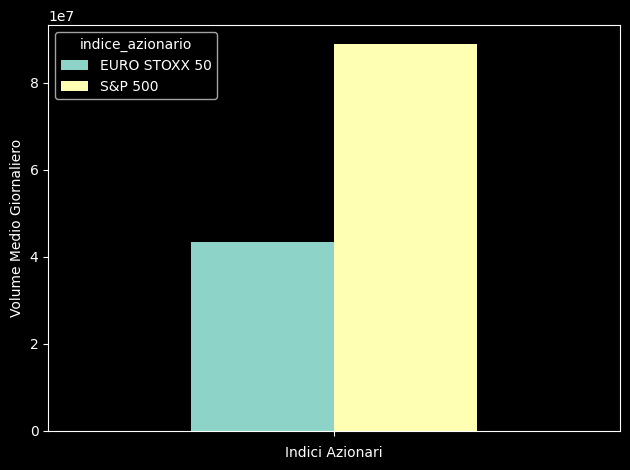

In [ ]:
q4_df = pd.DataFrame({
    "indice_azionario": ["EURO STOXX 50", "S&P 500"],
    "volume_medio_giornaliero": [
        euro_50_df_featured['Volume'].mean().round(),
        sp_500_df_featured['Volume'].mean().round()
    ]
})
q4_df = q4_df.set_index(["indice_azionario"])
# Metodo comodo per trasformare indice in colonne e viceversa
q4_df = q4_df.transpose()
q4_df = q4_df.astype(int)
display(q4_df)
q4_plot_barchart(q4_df, "Indici Azionari", "Volume Medio Giornaliero")

##### 3.4.4.2 Conclusioni - Q4

Il volume medio giornaliero per S&P 500 è più del doppio rispetto a EURO STOXX 50.

## 4. Model (Modellare il dato)

Non avendo ancora le competenze di ambito AI e Data Science rimando lo svolgimento di questo punto a momenti futuri. Lascio ugualmente il punto per garantire un applicazione rigorosa del framework OSEMN.

## 5. iNterpret (Comunicare il risultato)

Procederò nella sezione seguente ad illustrare gli insights chiave pervenuti dall'analisi dei Qx richiesti al fine di aiutare gli investitori a prendere decisioni strategiche.

### 5.1 Q1 - Insights su Rendimenti percentuali e cumulativi

S&P 500, negli ultimi 10 anni, è cresciuto in misura nettamente maggiore dell'EURO STOXX 50. Seguendo il principio base di **diversificazione** della [Modern Portfolio Theory di Harry Markowitz](https://en.wikipedia.org/wiki/Modern_portfolio_theory), la famosa regola del "non mettere tutte le uova nello stesso paniere", si può dare più spazio al mercato USA senza abbandonare l’Europa. Un taglio pratico potrebbe essere questo:

* **65-70 % “core” sul mercato USA** (ETF che replicano l'S&P 500): è la fetta principale perché il listino americano ha mostrato storicamente rendimento e liquidità superiori.
* **20-25 % “satellite” sull'Europa** (ETF EURO STOXX 50 o fondi simili): serve a ridurre il rischio di puntare su una sola area geografica e a beneficiare di eventuali fasi in cui l’Europa recupera terreno.
* **10-15 % cuscinetto difensivo** (cash, obbligazioni di breve durata, oro o un mix): aiuta ad attenuare i colpi nelle fasi turbolente e fornisce munizioni da usare se i mercati scendono.

Questa ripartizione si ispira al modello [core-satellite](https://www.investopedia.com/articles/financial-theory/08/core-satellite-investing.asp) usato da molti gestori: il "core" passivo e largo (S&P 500) dà stabilità e bassi costi, mentre i "satelliti" (Europa e strumenti difensivi) servono per equilibrare e cogliere opportunità diverse.



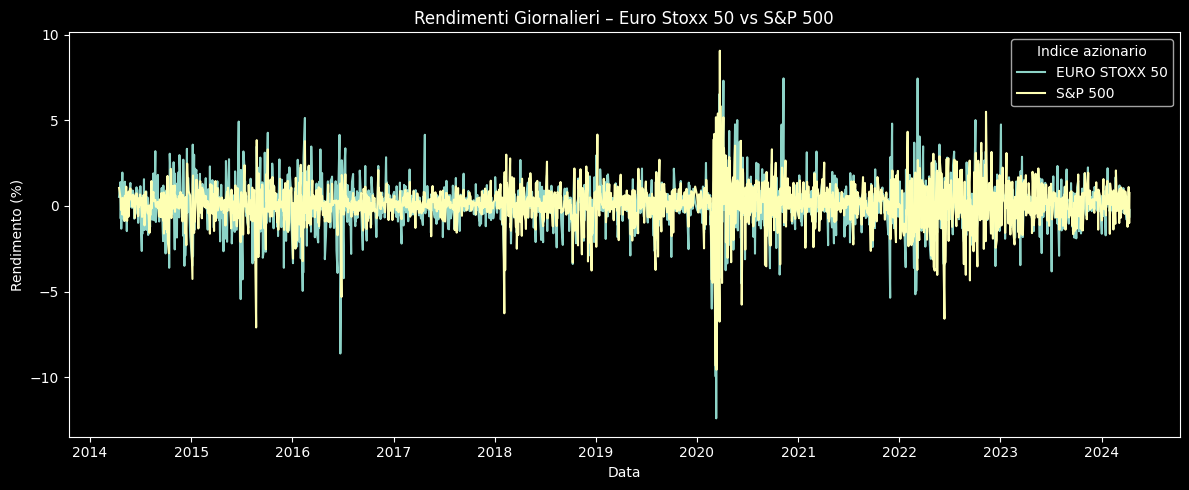

In [ ]:
q1_line_chart(
    df = q1_df_giornaliero,
    title = "Rendimenti Giornalieri – Euro Stoxx 50 vs S&P 500",
    ylabel = "Rendimento (%)",
    xlabel = "Data",
    legend_title = "Indice azionario"
    )

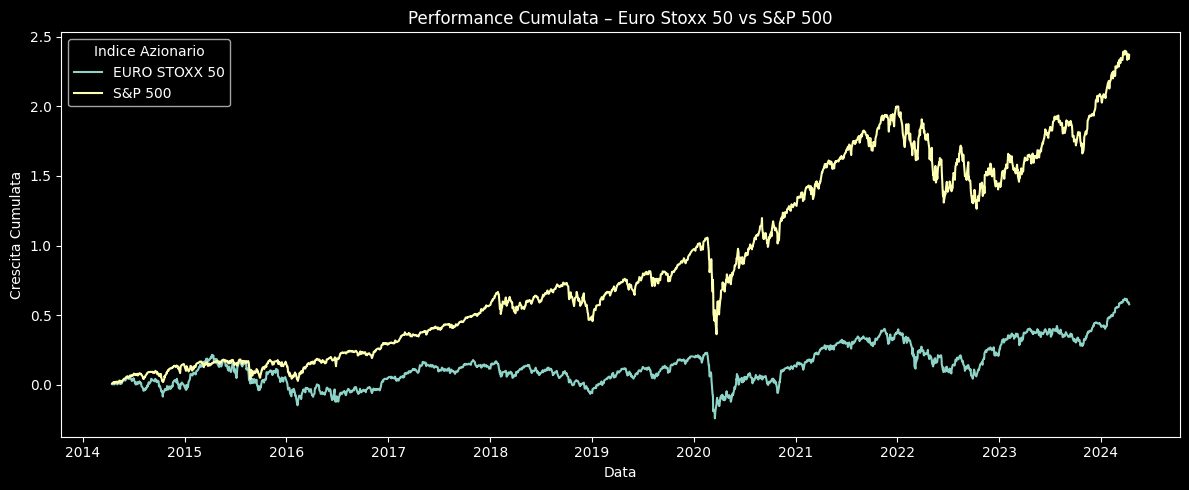

In [ ]:
q1_line_chart(
    df = q1_df_giornaliero_cumulative,
    title = "Performance Cumulata – Euro Stoxx 50 vs S&P 500",
    ylabel = "Crescita Cumulata",
    xlabel = "Data",
    legend_title = "Indice Azionario"
    )

### 5.2 Q2 - Insights

S&P 500 mostra un "reverse-weekend effect" positivo il Lunedì, mentre EURO STOXX 50 è più debole a metà settimana. In virtù di questa evidenza, se devo comprare qualcosa sull’S&P 500, proverei a farlo il Lunedì mattina, mentre sugli strumenti europei preferirei Lunedì ed eviterei grossi acquisti il Mercoledì.

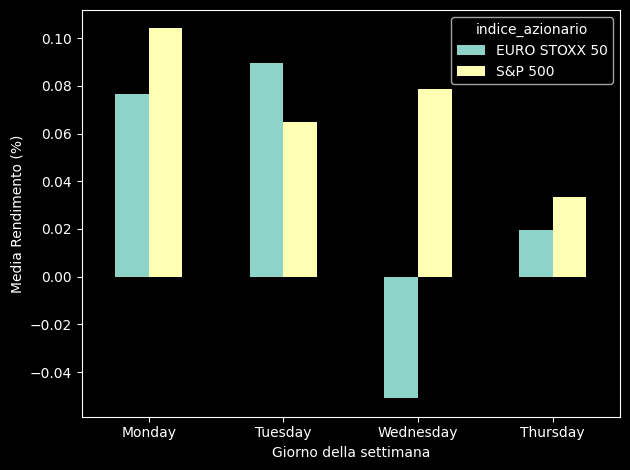

In [ ]:
q2_plot_barchart(q2_df, "Giorno della settimana", "Media Rendimento (%)")

### 5.3 Q3 - Insights

Gli shock globali (es. COVID-19) colpiscono entrambi i mercati, mentre gli eventi locali (es. Brexit) impattano soprattutto l'area geografica interessata. Questa problematica è evitabile applicando la strategia proposta per il quesito Q1. La percentuale di beni rifugio difende contro le crisi globali e la diversificazione difente dalle crisi locali. In questi casi si raccomanda, come meccanismo di prevenzione aggiuntivo, il fare piccoli ribilanciamenti preventivi per il medio termine se si hanno sospetti fondati di crisi in arrivo.

### 5.4 Q4 - Insights

S&P 500 scambia oltre il doppio dei volumi medi dell'EURO STOXX 50, di conseguenza:
- Su S&P 500 si ha spred ridotto sugli asset e slippage (tempo per completare un ordine) minore.
- Su EURO STOXX 50 si ha spred maggiore sugli asset e slippage (tempo per completare un ordine) maggiore soprattutto per grandi capitali.

A livello operativo, negli USA non mi farei problemi a piazzare ordini corposi in una singola operazione, mentre in Europa li dilazionerei in più tranche per minimizzare il movimento di prezzo. In riferimento alle operazioni dilazionate nel tempo, esistono metodologie applicate dalle così dette "whale" — grandi fondi e desk istituzionali, come ad esempio gli algoritmi di tipo [VWAP](https://blog.quantinsti.com/vwap-strategy/?utm_source=google&utm_medium=cpc&utm_campaign=epat_reach_tofu_dsa_row&utm_content=&gad_source=1&gad_campaignid=22129587091&gbraid=0AAAAAD2T4TCskmbqrJEpBNRRMIMo4NXcS&gclid=CjwKCAjwravBBhBjEiwAIr30VEsa6JM1zlxB6Uj_F5XXtjas4rZIJYsmnORpGA2K0ITRo06vgtwo0BoCuGIQAvD_BwE).

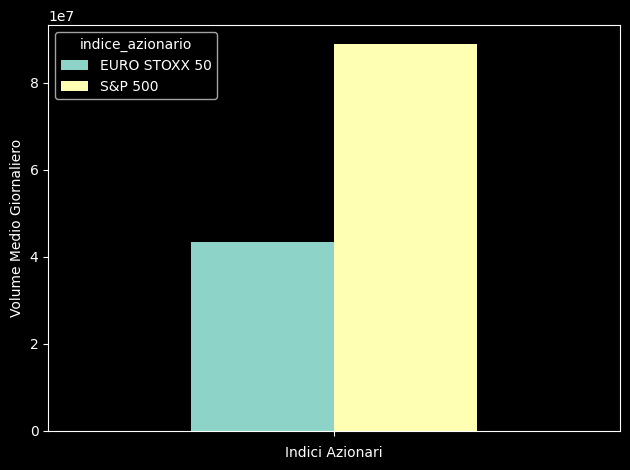

In [ ]:
q4_plot_barchart(q4_df, "Indici Azionari", "Volume Medio Giornaliero")